In [1]:
import h5py
import numpy as np    
import matplotlib.pyplot as plt
import os
import argparse
import tqdm
from matplotlib.animation import FuncAnimation, PillowWriter
%matplotlib widget

datafolder = '/travail/xgong/new_simu_highppc/output/mi25-MA40-PPC300'
datafolder = "/travail/xgong/test_separate/output/mi25-MA40"
plt.rcParams.update({
    # "text.usetex": True,
    "font.family": 'STIXGeneral',
    "text.latex.preamble": r"\usepackage{lmodern}",
    'mathtext.fontset': 'cm'
})

os.system('ls '+ os.path.join(datafolder, 'fields/*h5') + ' > ' + os.path.join(datafolder, 'filelist_flds.txt'))
with open(os.path.join(datafolder, 'filelist_flds.txt')) as f:
    files = f.readlines()
    for i in range(len(files)):
        files[i] = files[i].strip()
print(len(files))
fs = 15
fstick = 12


import scipy.ndimage.filters as filters

def smooth( x, window_len=61, window='hanning'):
    return filters.convolve1d(x, np.ones(window_len)/window_len)


400


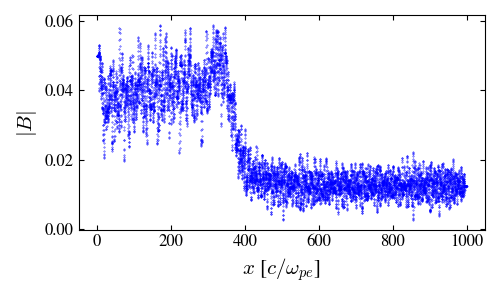

In [2]:
x =-1

file = h5py.File(files[x],'r+')['Step0']
x1 = (np.array(file['X1']))
idx = np.where((x1 > 0) & (x1 < 1000))[0]
x1 = x1[idx]
Exmean = np.array(file['fAvgEx'])[idx]/10
B3mean = np.array(file['fAvgBz'])[idx]/10
E2mean = np.array(file['fAvgEy'])[idx]/10
Exjpt = np.array(file['fJptEx'])[idx]#/25
J1 = (np.array(file['fJ1']))[idx]
J2 = (np.array(file['fJ2']))[idx]
J3 = (np.array(file['fJ3']))[idx]
B1 = (np.array(file['fB1']))[idx]
B2 = (np.array(file['fB2']))[idx]
B3 = (np.array(file['fB3']))[idx]
E1 = (np.array(file['fE1']))[idx]
E2 = (np.array(file['fE2']))[idx]
E3 = (np.array(file['fE3']))[idx]
J2 = smooth(np.array(file['fJ2']), window_len=4)[idx]
N1 = smooth(np.array(file['fN_1']))[idx]
N2 = smooth(np.array(file['fN_2']))[idx]

uExB = (E2mean/B3mean)
plt.figure(figsize = (5,3))
# plt.scatter(x1, smooth(N1,window_len=50)-smooth(N2,window_len=50) , color = 'red', s = 0.1)
plt.scatter(x1, B3, color = 'blue', s = 0.1)
# plt.ylim(-0.01,0.01)
plt.ylabel(r"$|B|$ ", fontsize = 15)
# plt.ylabel(r"$N$", fontsize = 15)
plt.xlabel(r'$x$ [$c / \omega_{pe}$]', fontsize= 15)
plt.tight_layout()
plt.tick_params(which='minor', direction='in', length=3, width=0.5, colors='k', grid_color='r', grid_alpha=0.5, labelsize=fstick)
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=fstick)
# plt.savefig("./plots/Bmean.png", dpi=500, bbox_size='tight')


Text(0, 0.5, 'P')

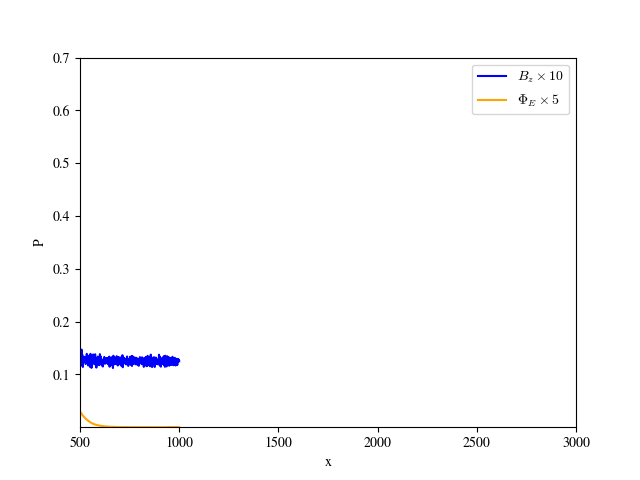

In [5]:
x =-1

mr =25

file = h5py.File(files[x],'r+')['Step0']
T11_e = np.array(file['fT11_1'])
T22_e = np.array(file['fT22_1'])
T11_i = np.array(file['fT11_2'])
# print(file.keys())
T22_i = np.array(file['fT22_2'])
B3 = np.array(file['fB3'])
Exmean = np.array(file['fAvgEx'])/10
x1 = np.array(file['X1'])
t_sim = np.array(file['Time'])
def integrate(x,y):
    return ((y[1:]+ y[:-1])/2*(x[1:] - x[:-1])).sum()

def stepintegrate(x,y):
    res = np.zeros_like(y)
    res = (np.cumsum(y[::-1]) * (x[1]-x[0]))[::-1]
    return res

x1 = np.array(file['X1'])
phi = stepintegrate(x1, Exmean)

plt.figure()
plt.plot(x1, smooth(B3) * 10 ,markersize = 0.01,linestyle='-', color = 'blue', label=r'$B_z \times 10$')
plt.plot(x1, phi * 5 ,markersize = 0.01,linestyle='-', color = 'orange', label=r'$\Phi_E \times 5$')

plt.legend()
# plt.scatter(x1, smooth(T11_i*mr**2),s = 0.01, color = 'red')
plt.ylim(1e-5,0.7)
plt.xlim(500,3000)
# plt.yscale('log')
plt.xlabel("x")
plt.ylabel("P")